# Numerical Model

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class RegressionNumericalView:
    def __init__(self):
        self.B_0 = 0
        self.B_1 = 0
        self.loss_history = []

    def fit(self, X, y, lr=0.01, epochs=1000, l1=0, l2=0):
        n = float(len(X))
        self.B_0, self.B_1 = 0, 0 
        self.loss_history = []
        
        for i in range(epochs):
            y_pred = self.B_0 + self.B_1 * X
            
            # 1. Gradients
            D_B0 = (-2/n) * np.sum(y - y_pred)

            D_B1 = ((-2/n) * np.sum(X * (y - y_pred))) + (l1 * np.sign(self.B_1)) + (2 * l2 * self.B_1)
            
            self.B_0 -= lr * D_B0
            self.B_1 -= lr * D_B1

            mse = (1/n) * np.sum((y - y_pred)**2)
            self.loss_history.append(mse)
        return self

    def predict(self, X):
        return self.B_0 + self.B_1 * X

def get_r2(y, y_pred):
    return 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))

Predicting Charges using BMI
train the model using **Lasso** and **Ridge**

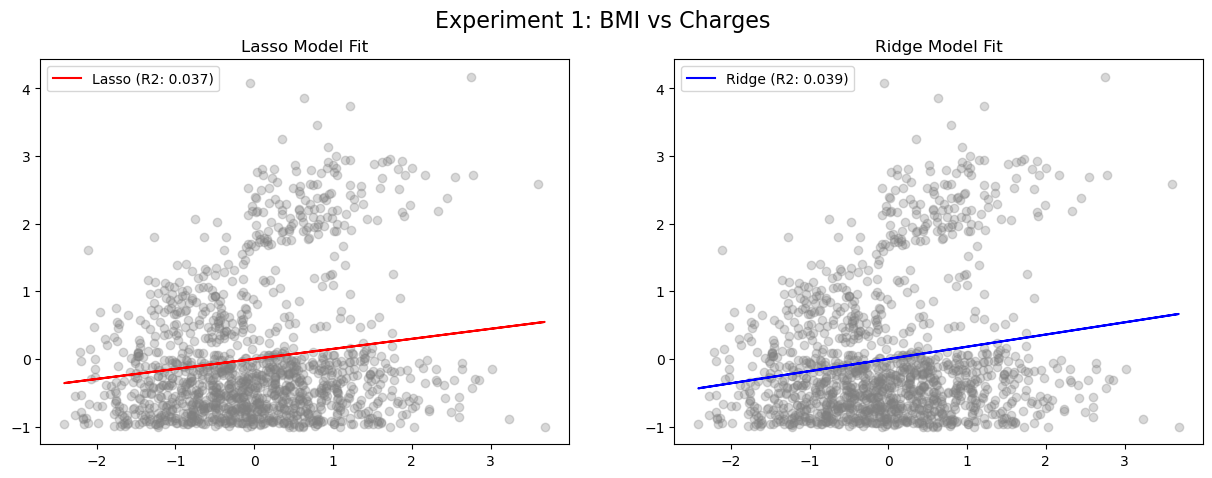

In [20]:

df= pd.read_csv(r"C:\Users\Ahmed Sobhy\Downloads\insurance.csv")

y_raw = df['charges'].values
y_scaled = (y_raw - y_raw.mean()) / y_raw.std()

X_bmi = df['bmi'].values
X_bmi_scaled = (X_bmi - X_bmi.mean()) / X_bmi.std()

#Train lasso
model_lasso = RegressionNumericalView().fit(X_bmi_scaled, y_scaled, l1=0.1, l2=0)
#Train ridge
model_ridge = RegressionNumericalView().fit(X_bmi_scaled, y_scaled, l1=0, l2=0.1)

# lasso and ridge plots
plt.figure(figsize=(15, 5))
plt.suptitle('Experiment 1: BMI vs Charges', fontsize=16)

#Lasso
plt.subplot(1, 2, 1)
plt.scatter(X_bmi_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_bmi_scaled, model_lasso.predict(X_bmi_scaled), color='red', label=f'Lasso (R2: {get_r2(y_scaled, model_lasso.predict(X_bmi_scaled)):.3f})')
plt.title('Lasso Model Fit')
plt.legend()

# Ridge 
plt.subplot(1, 2, 2)
plt.scatter(X_bmi_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_bmi_scaled, model_ridge.predict(X_bmi_scaled), color='blue', label=f'Ridge (R2: {get_r2(y_scaled, model_ridge.predict(X_bmi_scaled)):.3f})')
plt.title('Ridge Model Fit')
plt.legend()
plt.show()

apply charges using age

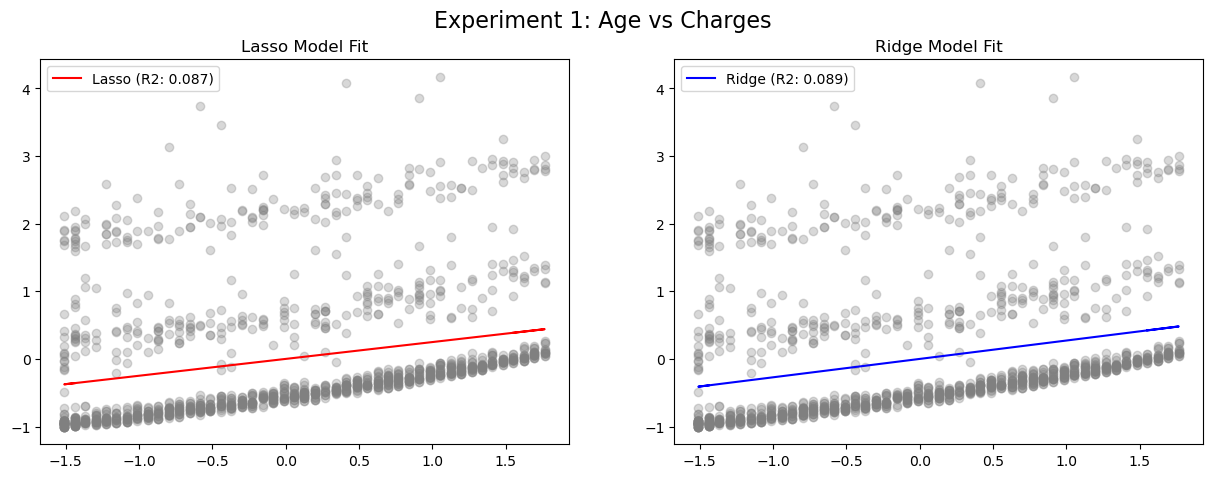

In [22]:
X_age= df['age'].values
X_age_scaled = (X_age - X_age.mean()) / X_age.std()

#Train lasso
model_lasso = RegressionNumericalView().fit(X_age_scaled, y_scaled, l1=0.1, l2=0)
#Train ridge
model_ridge = RegressionNumericalView().fit(X_age_scaled, y_scaled, l1=0, l2=0.1)

# lasso and ridge plots
plt.figure(figsize=(15, 5))
plt.suptitle('Experiment 1: Age vs Charges', fontsize=16)

#Lasso
plt.subplot(1, 2, 1)
plt.scatter(X_age_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_age_scaled, model_lasso.predict(X_age_scaled), color='red', label=f'Lasso (R2: {get_r2(y_scaled, model_lasso.predict(X_age_scaled)):.3f})')
plt.title('Lasso Model Fit')
plt.legend()

# Ridge
plt.subplot(1, 2, 2)
plt.scatter(X_age_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_age_scaled, model_ridge.predict(X_age_scaled), color='blue', label=f'Ridge (R2: {get_r2(y_scaled, model_ridge.predict(X_age_scaled)):.3f})')
plt.title('Ridge Model Fit')
plt.legend()
plt.show()